# STL-10

Generate STL-10 covariance in float64

In [2]:
import numpy as np
import numpy
import matplotlib.pyplot as plt
from torchvision.datasets import STL10
from torchvision import transforms

# Load STL-10 unlabeled images
ds = STL10(
    root="./data",
    split="unlabeled",
    download=True,
    transform=transforms.ToTensor(),
)

n = 16000
p = 96 * 96 * 3

# Build data matrix X: n x p
X = np.empty((n, p), dtype=np.float64)
for i in range(n):
    img, _ = ds[i]
    X[i] = img.numpy().reshape(-1).astype(np.float64)

# Remove per-image brightness and contrast
X -= X.mean(axis=1, keepdims=True)
X /= X.std(axis=1, keepdims=True) + 1e-12

# Center and standardize features
X -= X.mean(axis=0, keepdims=True)
X /= X.std(axis=0, keepdims=True) + 1e-12

# Gram covariance A = XX^T / p
A = (X @ X.T) / p

# Eigenvalues
eig = np.linalg.eigvalsh(A)
eig[eig < 0] = 0.0

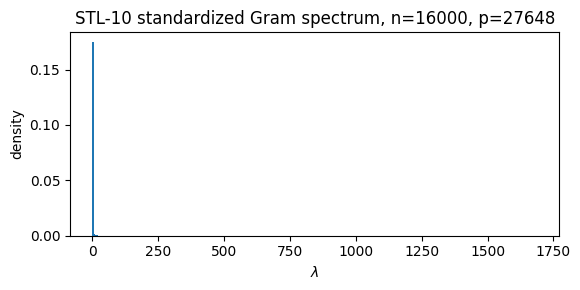

In [3]:
# Linear-scale spectrum
plt.figure(figsize=(6, 3))
plt.hist(eig, bins=300, density=True)
plt.xlabel(r"$\lambda$")
plt.ylabel("density")
plt.title(f"STL-10 standardized Gram spectrum, n={n}, p={p}")
plt.tight_layout()
plt.show()

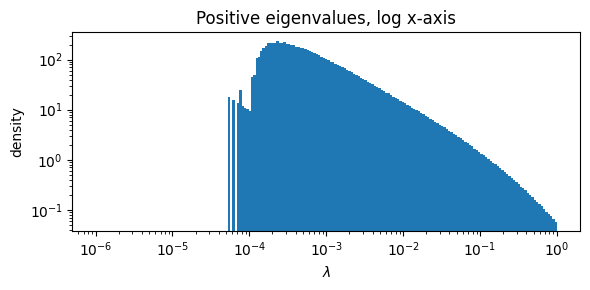

In [4]:
# Log x-axis diagnostic
plt.figure(figsize=(6, 3))

bins = numpy.geomspace(1e-6, 1e0, 200)
plt.hist(eig[eig > 1e-12], bins=bins, density=True)
plt.yscale('log')
plt.xscale("log")
plt.xlabel(r"$\lambda$")
plt.ylabel("density")
plt.title("Positive eigenvalues, log x-axis")
plt.tight_layout()
plt.show()

In [7]:
np.save("/data/sameli/free-algebraic/stl10_n16K.npy", A)